In [3]:
!pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 71.2 MB/s eta 0:00:00


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

In [5]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/flights.csv"
df = pd.read_csv(url)
df.head()

,year,month,passengers
0,1949,January,112
1,1949,February,118
2,1949,March,132
3,1949,April,129
4,1949,May,121


In [6]:
df.tail()

,year,month,passengers
139,1960,August,606
140,1960,September,508
141,1960,October,461
142,1960,November,390
143,1960,December,432


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   year        144 non-null    int64 
 1   month       144 non-null    object
 2   passengers  144 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 3.5+ KB


In [8]:
df.columns

Index(['year', 'month', 'passengers'], dtype='object')

In [9]:
df.shape

(144, 3)

In [10]:
df.isnull().sum()

,0
year,0
month,0
passengers,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df = df.drop_duplicates()
df.isnull().sum()

,0
year,0
month,0
passengers,0


In [20]:
df.to_csv("cleaned_flights.csv", index=False)
print("Cleaned CSV file created successfully!")

Cleaned CSV file created successfully!


In [13]:
print("Total Records:", len(df))
print("Total Years:", df["year"].nunique())
print("Total Months:", df["month"].nunique())
print("Average Passengers:", df["passengers"].mean())
print("Maximum Passengers:", df["passengers"].max())

Total Records: 144
Total Years: 12
Total Months: 12
Average Passengers: 280.2986111111111
Maximum Passengers: 622


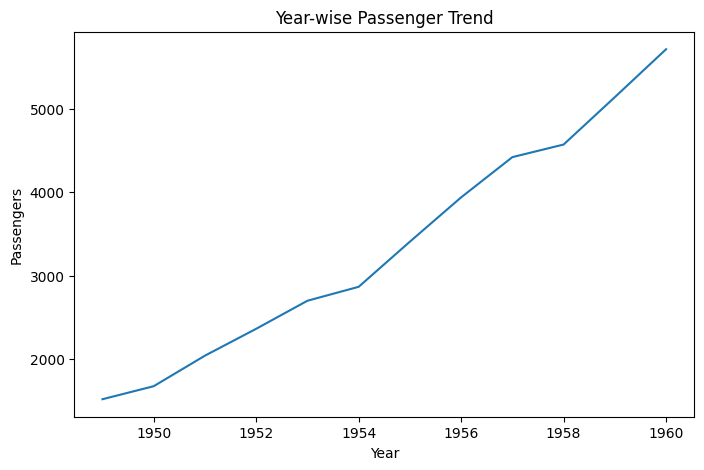

In [14]:
#Year wise passengers trend
yearly = df.groupby("year")["passengers"].sum()
plt.figure(figsize=(8,5))
plt.plot(yearly.index, yearly.values)
plt.title("Year-wise Passenger Trend")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.show()

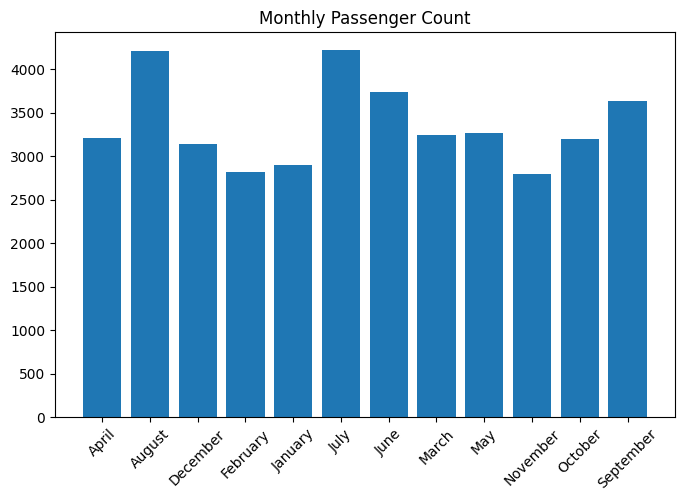

In [15]:
#Monthly pasenger count
monthly = df.groupby("month")["passengers"].sum()
plt.figure(figsize=(8,5))
plt.bar(monthly.index, monthly.values)
plt.title("Monthly Passenger Count")
plt.xticks(rotation=45)
plt.show()

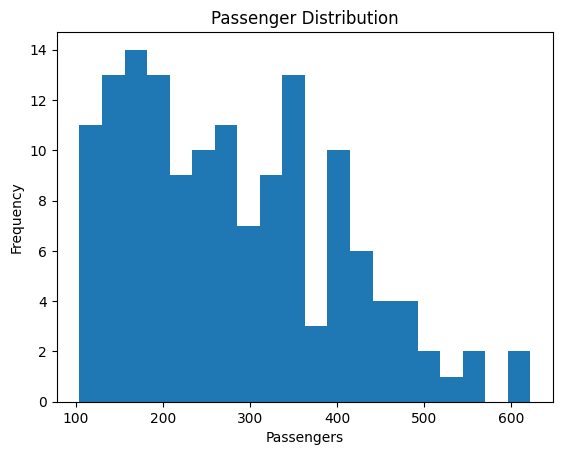

In [16]:
#Passenger count
plt.hist(df["passengers"], bins=20)
plt.title("Passenger Distribution")
plt.xlabel("Passengers")
plt.ylabel("Frequency")
plt.show()

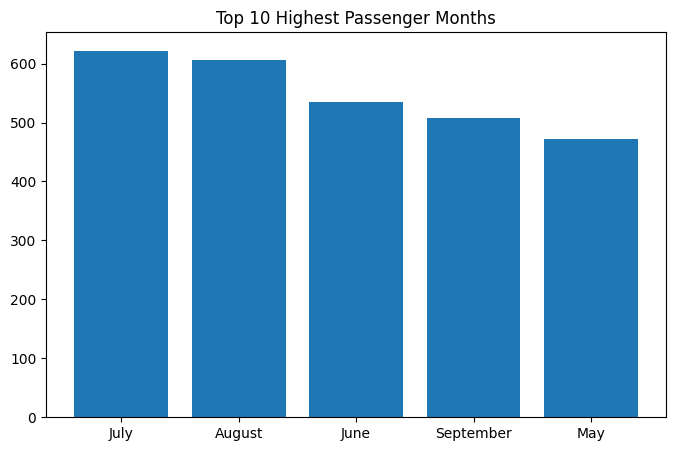

In [17]:
top10 = df.sort_values(by="passengers", ascending=False).head(10)
plt.figure(figsize=(8,5))
plt.bar(top10["month"], top10["passengers"])
plt.title("Top 10 Highest Passenger Months")
plt.show()

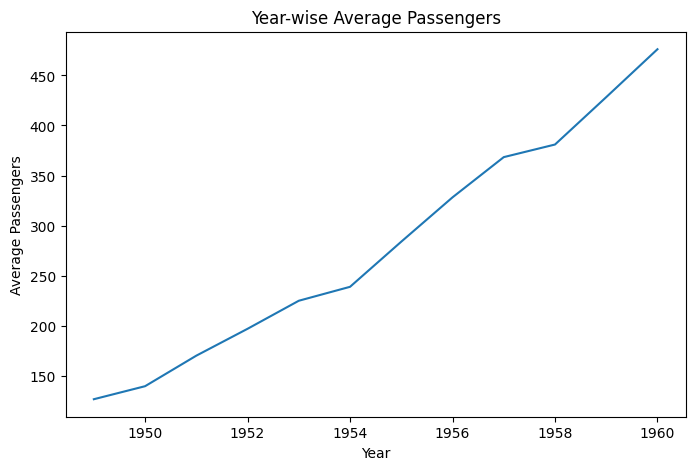

In [18]:
#Year wise passenger count
avg = df.groupby("year")["passengers"].mean()
plt.figure(figsize=(8,5))
plt.plot(avg.index, avg.values)
plt.title("Year-wise Average Passengers")
plt.xlabel("Year")
plt.ylabel("Average Passengers")
plt.show()